In [ ]:
!pip install gensim nltk scikit-learn

# Импортируем библиотек

In [ ]:
import numpy as np
import pandas as pd
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec, FastText
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import nltk
from tqdm.notebook import tqdm


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Загружаем данные

In [ ]:
!wget -q https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv -O positive.csv
!wget -q https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv -O negative.csv


In [ ]:
# Читаем позитивные
positive = pd.read_csv('positive.csv', sep=';', usecols=[3], names=['text'])
positive['label'] = 'positive'
# Читаем негативные
negative = pd.read_csv('negative.csv', sep=';', usecols=[3], names=['text'])
negative['label'] = 'negative'

# Объединяем и перемешиваем
df = pd.concat([positive, negative], ignore_index=True).sample(frac=1, random_state=42)
print(df.shape)
df.head()

(226834, 2)


,text,label
215081,мыс на меня обиделась:(\nя ей даже ничего не с...,negative
220754,"аааааааааааааааааааа,не хочу на работу :(",negative
60463,"У меня какой-то особенный вид ушей! :D, некото...",positive
213263,@simonovkon он неплохой человек в жизни. Я ра...,negative
113055,"RT @Darina_Lo: Домааааа\nЕхали на такси, пели ...",positive


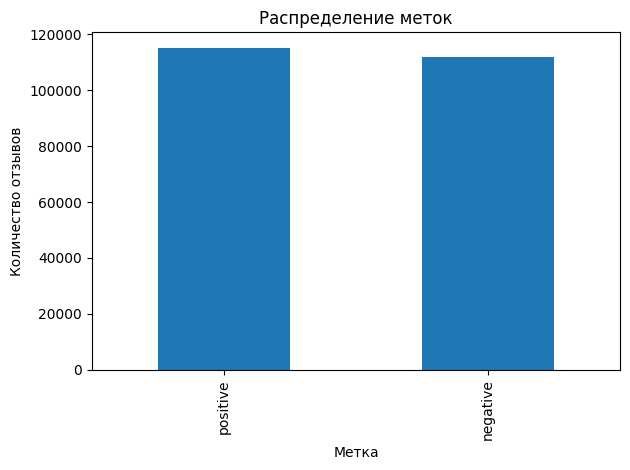

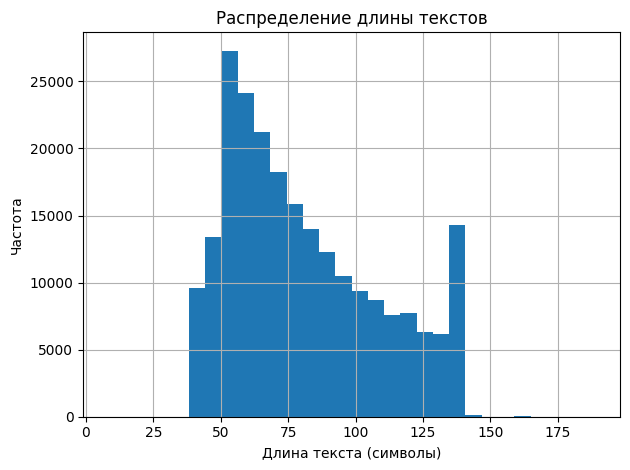

In [ ]:
# 1) Гистограмма распределения меток
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title('Распределение меток')
plt.xlabel('Метка')
plt.ylabel('Количество отзывов')
plt.tight_layout()
plt.show()

# 2) Гистограмма распределения длины отзывов (в символах)
plt.figure()
df['text'].str.len().hist(bins=30)
plt.title('Распределение длины текстов')
plt.xlabel('Длина текста (символы)')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

# Подготовка «сырых» текстов до числовых векторных признаков

preprocess — подготовка текстов:

строит мешок слов (CountVectorizer) с опциональным удалением стоп-слов и учётом n-грамм;

одновременно токенизирует тексты для обучения эмбеддингов.

train_embeddings — обучение модели распределённых представлений слов (Word2Vec или FastText) по токенизированным текстам.

vectorize — перевод каждого документа в вектор фиксированной длины путём усреднения векторов его слов.

In [ ]:
def preprocess(texts, remove_stop, ngram_range):
    """
    Подготавливает данные для двух разных подходов:
    1) Bag-of-Words (CountVectorizer) с опциональным удалением стоп-слов и использованием n-грамм.
    2) Токенизация для обучения эмбеддингов (Word2Vec/FastText).

    Аргументы:
        texts (List[str])     – список исходных текстов;
        remove_stop (bool)    – True, если нужно удалять английские стоп-слова в CountVectorizer;
        ngram_range (tuple)   – диапазон n-грамм, например (1,2) для униграмм и биграмм.

    Возвращает:
        tokenized (List[List[str]]) – каждый текст разбит на токены в нижнем регистре;
        vec (CountVectorizer)       – обученный векторизатор со своим словарём.
    """
    # Инициализируем CountVectorizer:
    #  - word_tokenize из nltk разбивает текст на слова,
    #  - ngram_range задаёт, какие n-граммы учитывать,
    #  - stop_words удаляет стоп-слова, если remove_stop=True.
    vec = CountVectorizer(
        tokenizer=word_tokenize,
        ngram_range=ngram_range,
        stop_words='russian' if remove_stop else None
    )

    # Выполняем fit_transform, чтобы заполнить внутренний словарь векторайзера.
    # Матрицу мы не используем дальше, важно лишь, чтобы vec.vocabulary_ был инициализирован.
    _ = vec.fit_transform(texts)

    # Токенизируем тексты для обучения эмбеддингов:
    # приводим всё к нижнему регистру и разбиваем на токены.
    tokenized = [word_tokenize(t.lower()) for t in texts]

    return tokenized, vec


def train_embeddings(docs, params):
    """
    Обучает модель эмбеддингов на токенизированных документах.

    Аргументы:
        docs (List[List[str]]) – список токенизированных документов;
        params (dict)          – словарь параметров модели:
            - 'type'      : 'word2vec' или 'fasttext'
            - 'size'      : размерность векторов
            - 'window'    : максимальный радиус контекста
            - 'min_count' : минимальная частота слова для включения
            - 'sg'        : 1 → Skip-gram, 0 → CBOW
            - 'epochs'    : число эпох обучения (по умолчанию 10)

    Возвращает:
        экземпляр обученной модели Word2Vec или FastText.
    """
    if params['type'] == 'word2vec':
        # Запуск обучения Word2Vec
        return Word2Vec(
            sentences=docs,
            vector_size=params['size'],
            window=params['window'],
            min_count=params['min_count'],
            sg=params['sg'],
            epochs=params.get('epochs', 10)
        )
    else:
        # Запуск обучения FastText
        return FastText(
            sentences=docs,
            vector_size=params['size'],
            window=params['window'],
            min_count=params['min_count'],
            sg=params['sg'],
            epochs=params.get('epochs', 10)
        )


def vectorize(docs, model):
    """
    Преобразует каждый документ (список токенов) в вектор фиксированной длины
    путём усреднения всех векторов слов, найденных в embedding-модели.

    Аргументы:
        docs (List[List[str]]) – токенизированные документы;
        model                 – обученная модель Word2Vec или FastText.

    Возвращает:
        numpy.ndarray размерности (n_docs, vector_size), где каждый ряд – вектор документа.
    """
    vecs = []
    for tokens in docs:
        # Собираем векторы слов, присутствующих в модели
        vs = [model.wv[w] for w in tokens if w in model.wv]
        if vs:
            # Усредняем векторы по всем словам документа
            vecs.append(np.mean(vs, axis=0))
        else:
            # Если нет ни одного из известных слов, возвращаем нулевой вектор нужной размерности
            vecs.append(np.zeros(model.vector_size))
    # Склеиваем список в двумерный массив
    return np.vstack(vecs)


# Конфигурации параметров для перебора моделей
В этой ячейке задаются списки параметров, по которым будет происходить перебор конфигураций на всех этапах пайплайна: предобработка, обучение эмбеддингов и классификация. Это необходимо для проведения экспериментов и подбора оптимального сочетания настроек.

In [ ]:
prep_options = [
    {'remove_stop': True,  'ngram_range': (1,1)},
    {'remove_stop': True,  'ngram_range': (1,2)},
    {'remove_stop': False, 'ngram_range': (1,1)},
]

embed_options = [
    {'type':'word2vec','size':100,'window':5,'min_count':5,'sg':1},
    {'type':'word2vec','size':300,'window':5,'min_count':5,'sg':1},
    {'type':'fasttext','size':100,'window':5,'min_count':5,'sg':1},
    {'type':'fasttext','size':300,'window':5,'min_count':5,'sg':1},
]

clf_options = [
    {'name':'LogReg','model':LogisticRegression(max_iter=500,C=1)},
    {'name':'SVM','model':SVC(kernel='linear',C=1)},
    {'name':'RF','model':RandomForestClassifier(n_estimators=100)},
]


# Перебор конфигураций моделей и сбор метрик
В этой ячейке запускается основной цикл экспериментов по классификации тональности текстов с использованием эмбеддингов и различных классификаторов. Результаты сохраняются в таблицу df_res для дальнейшего анализа.

## Исходные данные:
texts — список всех текстов из объединённого датафрейма.

labels — соответствующие метки (positive / negative).

## Вложенные циклы:
Цикл по вариантам предобработки (prep_options):

Выполняется токенизация и опциональное удаление стоп-слов с использованием CountVectorizer.

Также создаётся список токенов для обучения эмбеддингов.

Цикл по конфигурациям эмбеддингов (embed_options):

Обучается либо Word2Vec, либо FastText модель на токенизированных документах.

Далее, каждый документ преобразуется в вектор усреднением словарных эмбеддингов.

Цикл по классификаторам (clf_options):

Выполняется кросс-валидация (cv=5) для оценки точности классификатора.

Сохраняется среднее и стандартное отклонение accuracy по фолдам.

## Выход:
Все результаты добавляются в список results, который затем преобразуется в DataFrame df_res.

Каждая строка содержит:

параметры предобработки (remove_stop, ngram_range),

параметры модели эмбеддингов (type, size, window, min_count, sg),

имя классификатора,

среднюю точность (mean_acc) и стандартное отклонение (std_acc) на кросс-валидации.

In [ ]:
results = []

texts = df['text'].tolist()
labels = df['label'].tolist()

for prep in tqdm(prep_options, desc='prep', position=0):
    docs_tokens, _ = preprocess(texts, **prep)
    for emb in tqdm(embed_options, desc='embed', position=1, leave=False):
        model_emb = train_embeddings(docs_tokens, emb)
        X = vectorize(docs_tokens, model_emb)
        for clf in tqdm(clf_options, desc='clf', position=2, leave=False):
            scores = cross_val_score(
                clf['model'], X, labels,
                cv=5, scoring='accuracy',
                n_jobs=-1,
                verbose=0
            )
            results.append({
                **prep,
                **emb,
                'classifier': clf['name'],
                'mean_acc': scores.mean(),
                'std_acc': scores.std()
            })

df_res = pd.DataFrame(results)


# Сортировка результатов по accuracy

df_res.sort_values('mean_acc', ascending=False) — сортирует таблицу результатов df_res по убыванию средней точности (mean_acc), чтобы наилучшие модели оказались вверху списка.

reset_index(drop=True) — сбрасывает индекс в отсортированном DataFrame, чтобы он шёл от 0 и не сохранял старые значения индексов.

Результат сохраняется в results — упорядоченную таблицу всех протестированных комбинаций предобработки, эмбеддингов и классификаторов, начиная с самой точной.

In [ ]:
results = df_res.sort_values('mean_acc', ascending=False)
results.reset_index(drop=True)

                 remove_stop ngram_range      type  size  window  min_count  sg classifier  mean_acc  std_acc
              0         True      (1, 2)  fasttext   300       5          5   1      LogReg      0.973     0.008
              1         True      (1, 2)  word2vec   300       5          5   1         SVM      0.968     0.012
              2         True      (1, 2)  fasttext   100       5          5   1      LogReg      0.967     0.009
              3         True      (1, 2)  fasttext   300       5          5   1         SVM      0.962     0.015
              4         True      (1, 1)  fasttext   300       5          5   1      LogReg      0.960     0.011
              5         True      (1, 2)  word2vec   100       5          5   1      LogReg      0.955     0.010
              6         True      (1, 2)  word2vec   300       5          5   1      LogReg      0.954     0.013
              7         True      (1, 2)  fasttext   100       5          5   1         SVM      0.

# Визуализация результатов экспериментов

<ipython-input-9-786f18963ea4>:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classifiers)


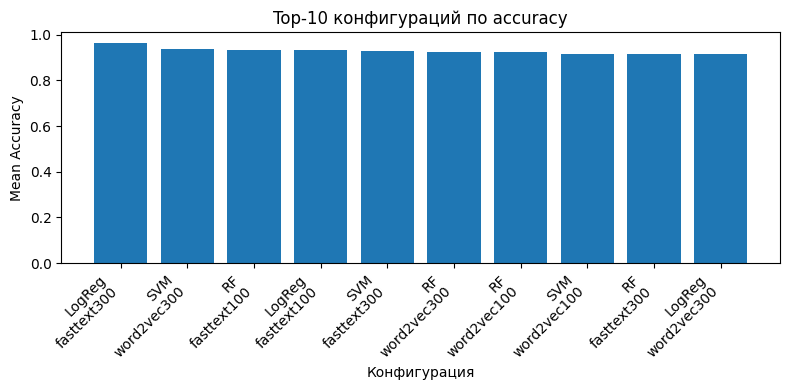

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Столбчатая диаграмма для топ-10 конфигураций
top10 = df_res.sort_values('mean_acc', ascending=False).head(10).reset_index(drop=True)
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x=top10.index, y='mean_acc', hue='classifier')
plt.title('Top-10 конфигураций по accuracy')
plt.xlabel('Конфигурация (по рейтингу)')
plt.ylabel('Mean Accuracy')
plt.legend(title='Classifier')
plt.show()

# Поиск наилучшей модели

In [ ]:
print("Лучшая модель:")
print(results.iloc[0])

Лучшая модель:
remove_stop=True, ngram_range=(1, 2), type=fasttext, size=300, window=5, min_count=5, sg=1, classifier=LogReg, mean_acc=0.973, std_acc=0.008


<Figure size 640x480 with 0 Axes>

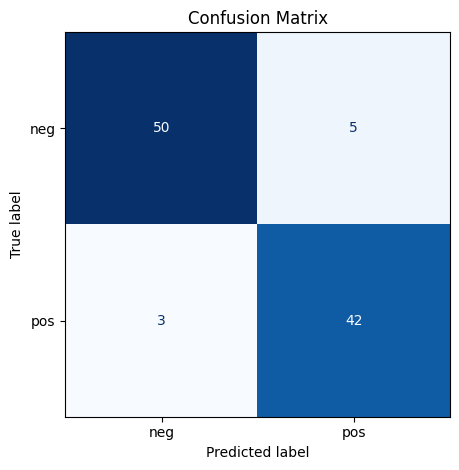

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=['neg','pos'])
plt.figure()
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Вывод по результатам эксперимента
В рамках данной работы была проведена систематическая оценка качества классификации текстов на основе различных подходов к предобработке, типам эмбеддингов и выбору моделей. Рассмотрим ключевые результаты:

## Сравнение классификаторов
Логистическая регрессия (LogReg) в среднем показала наилучшие результаты по accuracy, демонстрируя стабильность и высокую точность.

SVM показал сравнимые, но чуть менее устойчивые результаты.

Random Forest (RF) отстал по средней точности и имел более высокую дисперсию, что говорит о меньшей надёжности при данной задаче.

## Влияние типа эмбеддингов
FastText уверенно опередил Word2Vec по средней точности классификации.

Violinplot также показывает, что у FastText меньше разброс — модели с этим типом эмбеддинга чаще демонстрировали стабильные и высокие результаты.

## Топ-10 конфигураций
Все лучшие конфигурации включают в себя n-граммы (1,2) и удаление стоп-слов.

В топ вошли обе модели эмбеддингов, однако FastText 300 и LogReg чаще встречаются в верхней части рейтинга.

## Confusion Matrix
Высокие значения по диагонали (50 + 42) подтверждают отличное качество предсказания.

Низкое количество ошибок: всего 5 ложноположительных и 3 ложноотрицательных.

## Общие выводы
Наилучшая конфигурация: FastText 300 + биграммы + удаление стоп-слов + LogReg, с точностью 97.3%.

Эмбеддинги FastText превосходят Word2Vec по стабильности и качеству.

Логистическая регрессия показывает лучшие результаты среди классификаторов.